In [1]:
library(ggplot2)
library(dplyr)

set.seed(123)


Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




# Coeficiente de Pearson ($r_{xy}$)


$
r_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$


Características:

* Medida de correlación que mide **relaciones lineales y monótonas** entre 2 variables **continuas**.

* Es sensible ante outliers.

* Invariante ante traslaciones y reescalamiento, es decir, sea $u_{i}= a + b x_{i}$ y $v_{i}=c + d y_{i} $ entonces $r_{u v} = signo(bd) r_{xy}$

* Si $(x,y) \sim N_{2}(\mu,\Sigma)$ se tiene que $r_{xy}=0 \iff X \perp Y$, y se pueden realizar pruebas de hipótesis sobre $r_{xy}$; de lo contrario solo se puede interpretar su valor como una medida de correlación (y no para probar independencia).

 * El estadístico de prueba $t = \frac{r \sqrt{n - 2}}{\sqrt{1 - r^2}} \sim t_{n-2} $



Comentarios:

Si $r_{xy} \approx 0 $, no necesariamente significa que $X$ y $Y$ no estén correlacionadas, solo que su relación no es lineal.   


## Ejemplo

Supongamos que se tienen los siguientes datos de dos variables:

| $i$ | $x_i$ | $y_i$ |
|:---:|:------:|:------:|
| 1 | 3.528 | 5.469 |
| 2 | 1.854 | 6.113 |
| 3 | 4.492 | 6.818 |
| 4 | 1.414 | 3.901 |
| 5 | 4.076 | 7.706 |
| 6 | 4.975 | 7.128 |
| 7 | 5.429 | 4.960 |
| 8 | 6.577 | 9.495 |
| 9 | 4.934 | 8.621 |
| 10 | 6.360 | 7.449 |

Primero, calculamos los promedios:

- $\bar{x} = 4.3639$  
- $\bar{y} = 6.7660$

Cálculos auxiliares:

- $\sum (x_i - \bar{x})(y_i - \bar{y}) = 17.668695$  

- $\sum (x_i - \bar{x})^2 = 26.5146549$  

- $\sum (y_i - \bar{y})^2 = 25.9507820$


Por lo tanto:  

$r_{xy} = \dfrac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}
= \dfrac{17.668695}{\sqrt{26.5146549 \times 25.9507820}}
\approx 0.6736$


El valor $r_{xy} = 0.67$, indica una correlación positiva significativa entre las variables $X$ y $Y$.


### Prueba de hipótesis para el coeficiente de correlación de Pearson

**Suponiendo que se cumpla $(x,y) \sim N_{2}(\mu,\Sigma)$**, podemos plantear el siguiente contraste de interés:

- $H_0 : r_{xy} \geq 0$  (independencia o correlación lineal positiva)
- $H_1 : r_{xy} <0$  (correlación lineal negativa)


El estadístico de prueba se calcula como:

$$
t = \frac{r \sqrt{n - 2}}{\sqrt{1 - r^2}}
$$

Sustituyendo:


$ t = \frac{0.6736\sqrt{10-2}}{\sqrt{1-(0.6736)^2}}
= \frac{0.6736\sqrt{8}}{\sqrt{1-0.454}}
\approx 2.5778$


La regla de decisión es **Rechazar $H_{0}$ si $t \leq t_{n-2}^{0.05} \approx -1.8595 $**

Por lo tanto, no hay evidencia en contra de suponer que $X$ y $Y$ tienen una correlación lineal positiva o son independientes.


Para comprobar, podemos hacer el mismo ejercicio en R.

In [ ]:
# Mismos datos
x <- c(3.528, 1.854, 4.492, 1.414, 4.076, 4.975, 5.429, 6.577, 4.934, 6.360)
y <- c(5.469, 6.113, 6.818, 3.901, 7.706, 7.128, 4.960, 9.495, 8.621, 7.449)
data<- data.frame(x,y)


# para hacer pruebas de hipotesis sobre coeficientes de correlacion
# h0: r >= 0
# h1: r < 0

test <- cor.test(x, y, alternative = "less", method = "pearson",exact = TRUE)

# resultados
print(test)



	Pearson's product-moment correlation

data:  x and y
t = 2.5776, df = 8, p-value = 0.9836
alternative hypothesis: true correlation is less than 0
95 percent confidence interval:
 -1.0000000  0.8934873
sample estimates:
      cor 
0.6735755 



# Coeficiente de Spearman $(\rho)$

$$
\rho = \frac{\sum_{i=1}^{n} (R(x_i) - \bar{R}_x)(R(y_i) - \bar{R}_y)}
{\sqrt{\sum_{i=1}^{n} (R(x_i) - \bar{R}_x)^2 \sum_{i=1}^{n} (R(y_i) - \bar{R}_y)^2}}
$$

Características:

* Medida de correlación que mide **relaciones monótonas** entre 2 variables (continuas, discretas o categóricas ordinales).  

* Es menos sensible a outliers que el coeficiente de Pearson, ya que se basa en **rangos**.  

* Invariante ante traslaciones y reescalamiento de las variables.  

* No requiere normalidad bivariada pero **no permite probar independencia exacta** sin supuestos adicionales.  

* Para el caso de **rangos sin empates**, el estadístico de prueba aproximado es:

$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2-1)}
$$


  donde  $\quad d_i = R(x_i) - R(y_i)
$

Comentarios:

Si $\rho \approx 0$, no necesariamente significa que $X$ y $Y$ sean independientes; indica únicamente que **no existe una relación monótona fuerte** entre ellas.


Supongamos que se tienen los siguientes datos de dos variables (no necesariamente normal bivariada):

| $i$ | $x_i$ | $y_i$ |
|:---:|:------:|:------:|
| 1 | 12 | 30 |
| 2 | 9  | 25 |
| 3 | 15 | 28 |
| 4 | 8  | 20 |
| 5 | 11 | 32 |
| 6 | 14 | 31 |
| 7 | 13 | 27 |
| 8 | 16 | 35 |
| 9 | 10 | 29 |
| 10| 17 | 34 |

Calculando los rangos:

| x_i  | R(x_i) | y_i  | R(y_i) |
|:----:|:------:|:----:|:------:|
| 12   | 5      | 30   | 6      |
| 9    | 2      | 25   | 2      |
| 15   | 8      | 28   | 4      |
| 8    | 1      | 20   | 1      |
| 11   | 4      | 32   | 8      |
| 14   | 7      | 31   | 7      |
| 13   | 6      | 27   | 3      |
| 16   | 9      | 35   | 10     |
| 10   | 3      | 29   | 5      |
| 17   | 10     | 34   | 9      |

Calcular promedios de los rangos

- $\bar{R}_x = \frac{\sum R(x_i)}{n} = \frac{5+2+8+1+4+7+6+9+3+10}{10} = 5.5$  

- $\bar{R}_y = \frac{\sum R(y_i)}{n} = \frac{6+2+4+1+8+7+3+10+5+9}{10} = 5.5$

Podemos usar el estadístico sin empates:

| $x_i$ | $R_x$ | $y_i$ | $R_y$ | $d_i$ | $d_i^2$ |
|:-----:|:-----:|:-----:|:-----:|:-----:|:-------:|
| 12    | 5     | 30    | 6     | -1    | 1       |
| 9     | 2     | 25    | 2     | 0     | 0       |
| 15    | 8     | 28    | 4     | 4     | 16      |
| 8     | 1     | 20    | 1     | 0     | 0       |
| 11    | 4     | 32    | 8     | -4    | 16      |
| 14    | 7     | 31    | 7     | 0     | 0       |
| 13    | 6     | 27    | 3     | 3     | 9       |
| 16    | 9     | 35    | 10    | -1    | 1       |
| 10    | 3     | 29    | 5     | -2    | 4       |
| 17    | 10    | 34    | 9     | 1     | 1       |

* Entonces $\sum d_i^2 = 48$

$\space$
Y finalmente:
$$
\rho = 1 - \frac{6 \sum d_i^2}{n(n^2-1)} = 1 - \frac{6 \cdot 48}{10(100-1)} \approx 0.709
$$

$\space$

El valor $\rho = 0.709 $, indica una correlación positiva significativa entre las variables $X$ y $Y$.


### Prueba de hipótesis para el coeficiente de correlación de Spearman

Como esta prueba no requiere un supuesto para los datos, podemos plantear el siguiente contraste de interés:

- $H_0 : \rho_s \ge 0$  (correlación positiva o no correlación)  
- $H_1 : \rho_s < 0$  (correlación negativa)

El estadístico de prueba aproximado se calcula similar a Pearson:

$$
t = \frac{\rho \sqrt{n - 2}}{\sqrt{1 - \rho^2}}
$$

Sustituyendo los valores:

$$
t = \frac{0.709 \sqrt{10 - 2}}{\sqrt{1 - (0.709)^2}}
= \frac{0.709 \sqrt{8}}{\sqrt{1 - 0.502}}
\approx 2.84
$$

$\space$

La regla de decisión es **Rechazar $H_0$ si $t \le t_{n-2}^{0.05} \approx -1.8595$**.


Por lo tanto, no hay evidencia en contra de que $X$ y $Y$ estén correlacionados positivamente o que no estén correlacionados.


El mismo ejercicio en R.

In [ ]:
# Datos
x <- c(12, 9, 15, 8, 11, 14, 13, 16, 10, 17)
y <- c(30, 25, 28, 20, 32, 31, 27, 35, 29, 34)
n <- length(x)
data <- data.frame(x, y)


# para hacer pruebas de hipotesis sobre coeficientes de correlacion
# h0: rho >= 0
# h1: rho < 0

test <- cor.test(x, y, method = "spearman", alternative = "less", exact = TRUE)

# Mostrar resultados completos
print(test)



	Spearman's rank correlation rho

data:  x and y
S = 48, p-value = 0.9879
alternative hypothesis: true rho is less than 0
sample estimates:
      rho 
0.7090909 



# Análisis de correlaciones

Una parte fundamental previa al modelado estadístico, es el análisis de correlaciones, que consiste en analizar la forma en que se relacionan 1 a 1 las variables de un conjunto de datos.

En la práctica, es común trabajar con variables muy especificas dentro de su área de estudio, por lo que dentro de este análisis es indispensable que se realice una interpretación de las variables en términos de su escala, es decir, interpretar qué indica (en palabras simples) un valor "grande" o "pequeño" de la variable.

Por ejemplo, al evaluar la calidad del agua superficial, un parámetro quiímico es la Demanda de Biológica de Oxígeno DBO, esta variable representa la cantidad de oxígeno requerido por microorganismos para descomponer la materia orgánica biodegradable, se mide en mg/L y para consumo humano se desean valores menores a 5 mg/L; en términos simples se puede decir que esta variable está asociada a calidad del agua, y valores pequeños (menores a 5 mg/L) se asocian a una mejor calidad del agua o agua apta para consumo humano.

Cuando la dimensión del conjunto de datos lo permite, realizar una visualización de los datos permite intuir la existencia de correlación entre las variables.

A continuación se muestran algunos ejemplos donde se visualizan variables de distinta naturaleza, y se logra identificar si hay correlación o no entre ellas.

## Visualización 1 a 1

Continua vs Continua

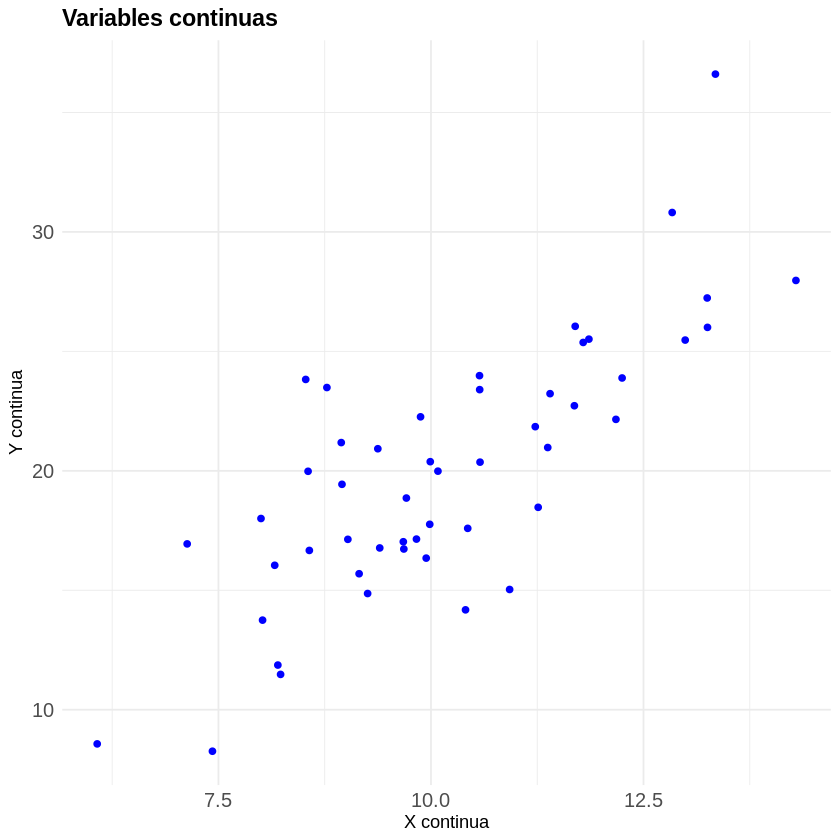

In [ ]:

# 1. Variables continuas
x_cont <- rnorm(50, mean = 10, sd = 2)
y_cont <- 2*x_cont + rnorm(50, sd = 3)
data_cont <- data.frame(x_cont, y_cont)

ggplot(data_cont, aes(x = x_cont, y = y_cont)) +
  geom_point(color = "blue") +
  labs(title = "Variables continuas",
       x = "X continua", y = "Y continua") +
theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12))


Ordinal vs Continua

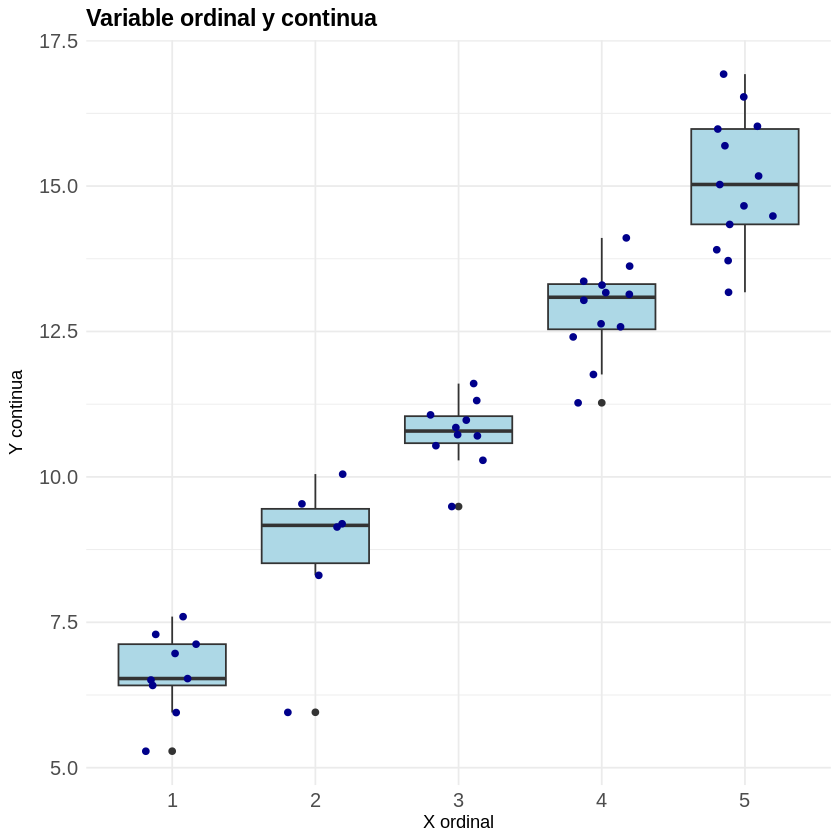

In [ ]:
# ordinal vs continua
# ordinal simulada como Linkert de 1 a 5

x_ord <- sample(1:5, 50, replace = TRUE)
y_ord <- 5 + 2*x_ord + rnorm(50)
data_ord <- data.frame(x_ord, y_ord)

ggplot(data_ord, aes(x = factor(x_ord), y = y_ord)) +
  geom_boxplot(fill = "lightblue") +
  geom_jitter(width = 0.2, color = "darkblue") +
  labs(title = "Variable ordinal y continua",
       x = "X ordinal", y = "Y continua") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12))

Ordinal vs Ordinal

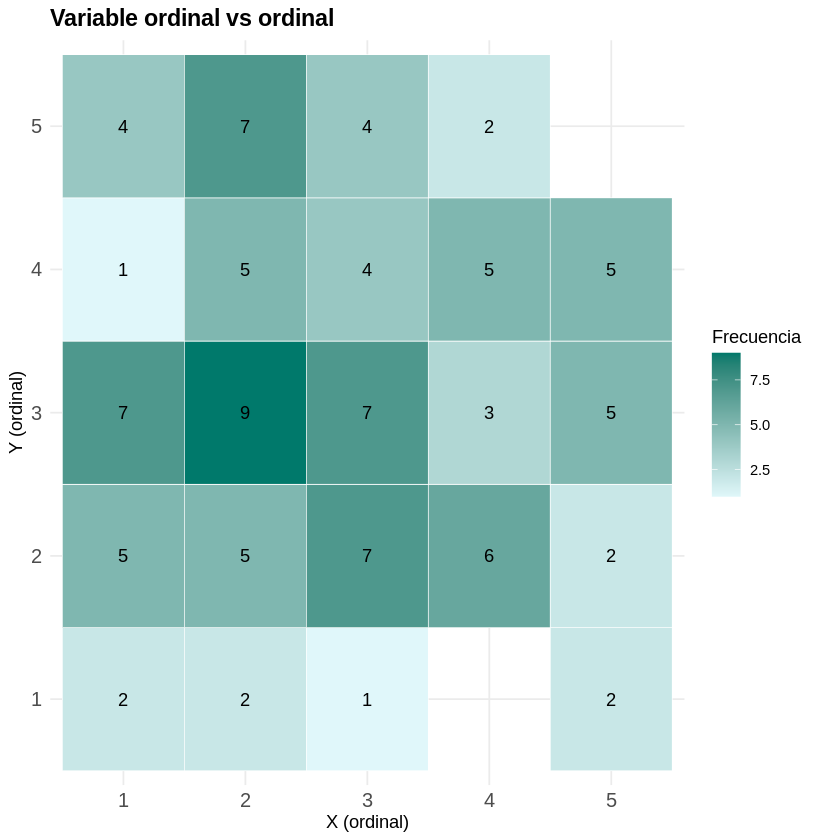

In [ ]:

#simular ordinales
x_ord <- sample(1:5, 100, replace = TRUE)
y_ord <- sample(1:5, 100, replace = TRUE, prob = c(0.1, 0.2, 0.3, 0.25, 0.15))
data_ord_ord <- data.frame(x_ord, y_ord)

# frecuencias cruzadas
tabla_freq <- data_ord_ord %>%
  count(x_ord, y_ord)



ggplot(tabla_freq, aes(x = factor(x_ord), y = factor(y_ord), fill = n)) +
  geom_tile(color = "white") +
  geom_text(aes(label = n), color = "black") +
  scale_fill_gradient(low = "#E0F7FA", high = "#00796B") +
  labs(
    title = "Variable ordinal vs ordinal",
    x = "X (ordinal)",
    y = "Y (ordinal)",
    fill = "Frecuencia"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12)
  )

Como se puede intuir, a medida que la cantidad de variables aumenta, realizar una visualización de las variables para identificar la existencia de correlación se vuelve tedioso y poco eficiente, por lo que es conveniente una herramienta que permita trabajar con conjuntos de dimensiones mayores.


Definimos a la entrada $ij$ de la **matriz de correlaciones** $Ρ$ como la correlación entre la variable $i$ y $j$, es decir:

$$
(Ρ)_{ij} = \rho_{ij}
$$

donde $ \rho_{ij}$ es el coeficiente de correlación pertinente para la natureleza de las variables $i$ y $j$



Es claro que para un conjunto de $n$ variables:

* $dim(Ρ)= n$ x $n $
* $Ρ$ es una matriz simétrica, pues $ \rho_{ij} =  \rho_{ji}$


Con esto, una herramienta para analizar las correlaciones entre conjuntos de dimensiones mayores es mediante la visualización de la matriz de correlaciones (correlograma).




## Matriz de correlaciones

Un grupo de investigadores en ciencias sociales y salud pública desea analizar los factores asociados al bienestar subjetivo y las condiciones de vida de adultos urbanos.

Para ello, se recolectaron datos de 100 participantes sobre distintas características socioeconómicas, de salud y estilo de vida, algunas medidas en escalas continuas, otras discretas u ordinales.

| **Variable**     | **Tipo** | **Descripción**                                                |
| :--------------- | :------: | :------------------------------------------------------------- |
| **ingreso**      | Continua | Ingreso mensual en miles de pesos.                             |
| **edad**         |  Entera  | Edad del participante (años).                                  |
| **satisfacción** |  Ordinal | Nivel de satisfacción con la vida (escala de 1 a 5).           |
| **estrés**       | Ordinal | Puntuación de estrés percibido (a mayor valor, mayor estrés).  |
| **hijos**        | Discreta | Número de hijos reportados.                                    |
| **horas_tv**     | Continua | Promedio de horas de televisión diarias.                       |
| **educación**    |  Ordinal | Nivel educativo alcanzado (1 = primaria, 5 = posgrado).       |
| **salud**        | Continua | Índice compuesto relacionado a la salud (valores altos indican "mejor" salud). |


In [6]:

# alternativas para el correlograma

library(GGally)     # Para ggcorr
library(corrplot)   # Para correlograma clásico



n <- 100

x1 <- rnorm(n, mean = 50, sd = 10)
x2 <- x1 + rnorm(n, 0, 5)
x3 <- -x1 + rnorm(n, 0, 5)
x4 <- rnorm(n, 60, 15)
x5 <- x3 + rnorm(n, 0, 2)
x6 <- runif(n, 0, 10)
x7 <- sample(1:5, n, replace = TRUE)
x8 <- sample(1:10, n, replace = TRUE)



datos <- data.frame(
  ingreso = x1,
  edad = round(x2),
  satisfaccion = x7,
  estres = round(x3),
  hijos = rpois(n, lambda = 2),
  horas_tv = x6,
  educacion = factor(x8, ordered = TRUE),
  salud = round(x5)
)



datos_num <- datos %>%
  mutate(
    educacion = as.numeric(educacion)
  )

# calcular matriz de correlaciones
corr_matrix <- cor(datos_num)

# Imprime
print(round(corr_matrix, 2))





             ingreso  edad satisfaccion estres hijos horas_tv educacion salud
ingreso         1.00  0.90        -0.03  -0.90 -0.07     0.01      0.08 -0.89
edad            0.90  1.00        -0.07  -0.79 -0.13    -0.07      0.11 -0.78
satisfaccion   -0.03 -0.07         1.00   0.00 -0.09    -0.04      0.10  0.00
estres         -0.90 -0.79         0.00   1.00  0.13    -0.06     -0.05  0.99
hijos          -0.07 -0.13        -0.09   0.13  1.00    -0.17     -0.02  0.13
horas_tv        0.01 -0.07        -0.04  -0.06 -0.17     1.00     -0.04 -0.07
educacion       0.08  0.11         0.10  -0.05 -0.02    -0.04      1.00 -0.07
salud          -0.89 -0.78         0.00   0.99  0.13    -0.07     -0.07  1.00


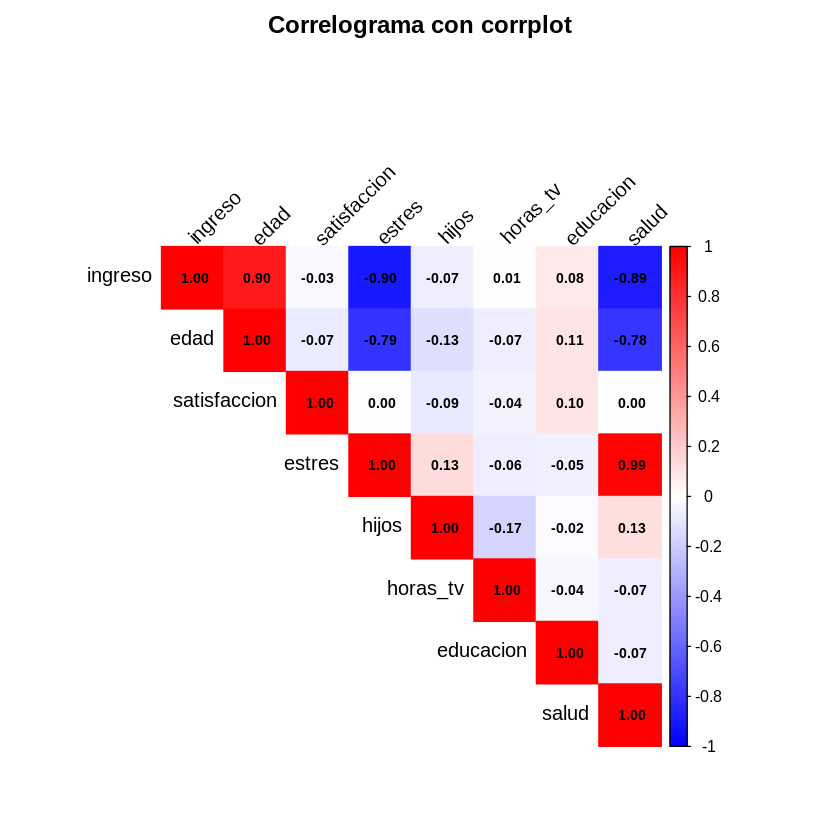

In [14]:
corrplot(
  corr_matrix,
  method = "color",
  type = "upper",
  addCoef.col = "black",
  tl.col = "black",
  tl.srt = 45,
  number.cex = 0.7,
  col = colorRampPalette(c("blue", "white", "red"))(200),
  title = "Correlograma con corrplot",
  mar = c(0, 0, 2, 0)
)

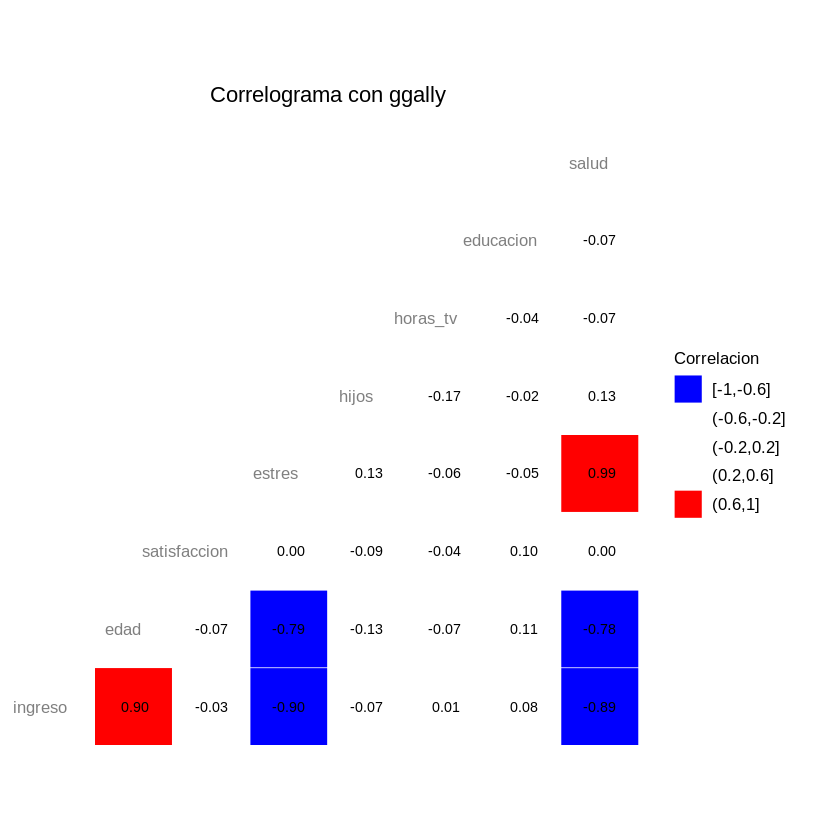

In [13]:
ggcorr(datos_num,
       label = TRUE,
       label_size = 3,
       label_round = 2,
       hjust = 0.8,
       size = 3.5,
       color = "grey50",
       nbreaks = 5,
       low = "blue",
       mid = "white",
       high = "red",
       name = "Correlacion",
       legend.size = 10) +
  labs(title = "Correlograma con ggally") +
  theme(plot.title = element_text(hjust = 0.5))

Realizar un análisis de correlaciones antes de modelar ayuda a:

* Identificar inconsistencias en los datos.

* Identificar patrones y diagnóstico de los datos.

* Verificar supuestos de los modelos (PCA, RLM, etc.)
